In [1]:
!nvidia-smi


Mon Feb  2 10:12:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q gradio torch diffusers transformers accelerate safetensors


In [3]:
import torch
import gradio as gr
from diffusers import StableDiffusionPipeline

MODEL_ID = "runwayml/stable-diffusion-v1-5"

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16
)
pipe.to(device)




Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [4]:
POSITIVE_STYLE = """
game environment concept art,
fantasy landscape, cinematic lighting,
epic scale, atmospheric depth,
high detail environment,
digital painting style,
unreal engine style,
dramatic sky, volumetric lighting
"""

NEGATIVE_STYLE = """
people, human, face, portrait,
logo, text, watermark,
cartoon, anime,
photo, photorealistic,
flat design, minimal,
low quality, blurry
"""






In [5]:
def generate_environment(prompt):
    if not prompt.strip():
        return None

    final_prompt = f"{POSITIVE_STYLE}, {prompt}"

    image = pipe(
        prompt=final_prompt,
        negative_prompt=NEGATIVE_STYLE,
        guidance_scale=7.5,
        num_inference_steps=30
    ).images[0]

    return image






  0%|          | 0/30 [00:00<?, ?it/s]

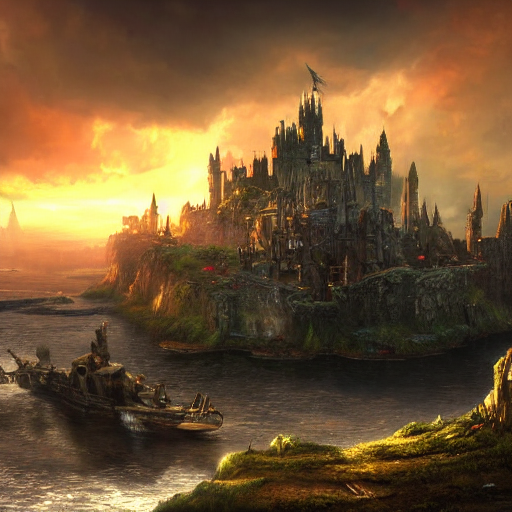

In [6]:
test = generate_environment(
    "ancient fantasy castle on a floating island, sunset, clouds below"
)
test






In [7]:
with gr.Blocks() as demo:
    gr.Markdown("""
    # 🎮 AI Game / Fantasy Environment Generator
    Generates **game environment concept art only**
    ❌ No characters | ❌ No logos | ❌ No photos
    """)

    prompt = gr.Textbox(
        label="Describe the game environment",
        placeholder="Example: dark fantasy forest with glowing mushrooms and mist"
    )

    btn = gr.Button("Generate Environment")
    output = gr.Image(type="pil", label="Generated Environment")

    btn.click(
        fn=generate_environment,
        inputs=prompt,
        outputs=output
    )

demo.launch(share=True)




Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc50a3de330eab6d72.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
